C:\Users\mbv16\PycharmProjects\pythonProject1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<class 'pandas.DataFrame'>
RangeIndex: 3732 entries, 5 to 3736
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sp500 volume         3732 non-null   float64
 1   sp500 high-low       3732 non-null   float64
 2   us_rates_%           3732 non-null   float64
 3   CPI                  3732 non-null   float64
 4   GDP                  3732 non-null   float64
 5   day                  3732 non-null   float64
 6   volatility_category  3732 non-null   int64  
 7   us_rates_diff        3732 non-null   float64
 8   us_rates_direction   3732 non-null   int64  
 9   eur_usd_return       3732 non-null   float64
 10  oil_diff             3732 non-null   float64
 11  gold_diff            3732 non-null   float64
 12  return_mean_5d       3732 non-null   float64
 13  return_std_5d        3732 non-null   float64
 14  volume_lag_1         3732 non-null   float64
 15  high-low_1           3732 non-null   float64
 16 

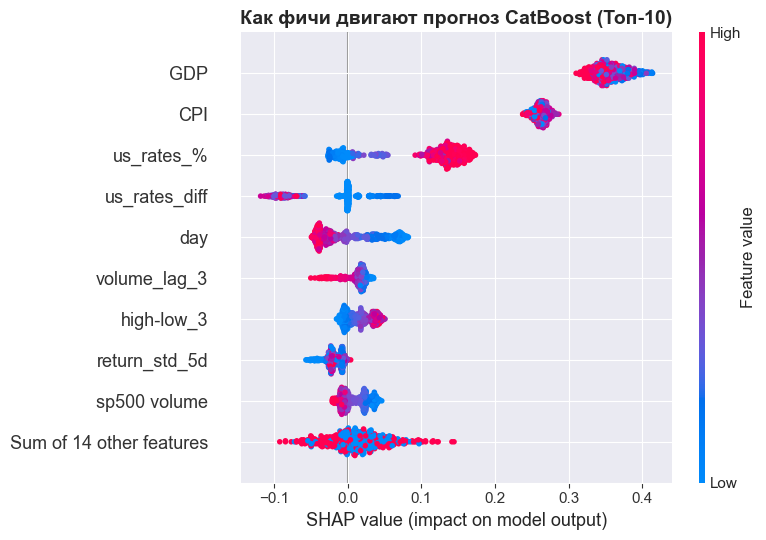

<Figure size 1000x600 with 0 Axes>

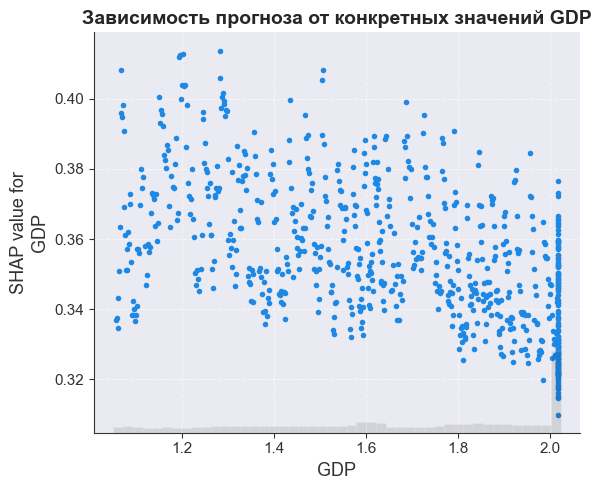

In [1]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from prompt_toolkit.key_binding.bindings.search import accept_search_and_accept_input
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from catboost import CatBoostClassifier

# 1. ЗАГРУЗКА ОЧИЩЕННОГО ДАТАСЕТА

df = pd.read_csv("financial_data_final_ML.csv")


# 2. РАЗДЕЛЕНИЕ НА МАТРИЦУ ПРИЗНАКОВ (X) И ТАРГЕТ (y)

df["sp500 return"] = df["sp500 close"].pct_change()
# Считаем кумулятивную (суммарную) доходность за СЛЕДУЮЩИЕ 5 дней
# rolling(5).sum() складывает доходность за 5 дней,
# а shift(-5) заглядывает вперед, перенося этот итог в сегодняшний день
df["target return"] =df["sp500 return"].rolling(5).sum().shift(-5)
df["target col"] = (df["target return"] > 0).astype(int)
df["us_rates_diff"] = df["us_rates_%"].diff()
df["us_rates_direction"] = (df["us_rates_diff"] > 0).astype(int)
df["eur_usd_return"] = df["eur_usd"].pct_change()
df["oil_diff"] = df["oil close"].pct_change()
df["gold_diff"] = df["gold close"].pct_change()
df["return_mean_5d"] = df["sp500 return"].rolling(5).mean()
df["return_std_5d"] = df["sp500 return"].rolling(5).std()
for lag in[1, 2, 3]:
    df[f"volume_lag_{lag}"] = df["sp500 volume"].shift(lag)
    df[f"high-low_{lag}"] = df["sp500 high-low"].shift(lag)
    df[f"gold_lag{lag}"] = df["gold_diff"].shift(lag)

df = df.dropna()


# Жестко удаляем все признаки текущего дня, которые дают модели подсказки (Data Leakage)
# Изолируем модель от ежедневного шума других рынков, оставляя только независимые факторы
columns_to_drop = [
    # Таргеты и S&P 500
    "sp500 open",
    "sp500 high",
    "sp500 low",
    "sp500 close",
    # Удаляем Nasdaq (чтобы убрать лик данных)
    "nasdaq open",
    "nasdaq high",
    "nasdaq low",
    "nasdaq close",
    "nasdaq volume",
    "nasdaq high-low",
    # Удаляем сырые цены металлов и товаров
    "silver open",
    "silver high",
    "silver low",
    "silver close",
    "silver volume",
    "silver high-low",
    "oil open",
    "oil high",
    "oil low",
    "oil close",
    "oil volume",
    "oil high-low",
    "platinum open",
    "platinum high",
    "platinum low",
    "platinum close",
    "platinum volume",
    "platinum high-low",
    "palladium open",
    "palladium high",
    "palladium low",
    "palladium close",
    "palladium volume",
    "palladium high-low",
    "gold open",
    "gold high",
    "gold low",
    "gold close",
    "gold volume",
    "sp500 return",
    "target return",
    "target col",
    "year",
    "eur_usd",
    "usd_chf",
    "month_1",
    "month_2",
    "month_3",
    "month_4",
    "month_5",
    "month_6",
    "month_7",
    "month_8",
    "month_9",
    "month_10",
    "month_11",
    "month_12",
]

# Создаем чистую матрицу признаков X
X = df.drop(columns = columns_to_drop)
print(X.info())
y = df["target col"]


split_index = int(len(df) * 0.8)
horizon = 5
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index + horizon:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index + horizon:]

print(f"Размер обучающей выборки (прошлое): {X_train.shape}")
print(f"Размер тестовой выборки (будущее в коробке): {X_test.shape}\n")


# 4. ОБУЧЕНИЕ БАЗОВОЙ МОДЕЛИ


clf_model = CatBoostClassifier(
    iterations=800,          # Можно дать чуть больше шагов, так как шаги стали короче
    depth=3,                 # Ультра-простые деревья, защищающие от зубрежки
    learning_rate=0.005,     # Очень осторожный шаг обучения
    l2_leaf_reg=5,           # Штраф за переобучение (L2 регуляризация)
    random_state=42,
    verbose=100
)
clf_model.fit(X_train, y_train)
y_train_pred = clf_model.predict(X_train)
y_test_pred = clf_model.predict(X_test)
#Вывод логики
importance = clf_model.get_feature_importance()
feature_names = list(X.columns)
feature_imp_df = pd.DataFrame({
    "Черта": feature_names,
    "Важность": importance
}).sort_values(by = "Важность", ascending = False)
#tree_rules = export_text(single_tree, feature_names = feature_names, max_depth = 3)
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)
#print(tree_rules)
print("=== ОЦІНКА МОДЕЛІ НАПРЯМКУ РИНКУ (Classification) ===")
print(f"Точність на навчанні (Train Accuracy): {acc_train:.4f}")
print(f"Точність на тесті (Test Accuracy):     {acc_test:.4f}")
print("=== На что смотрит дерево ===")
print(feature_imp_df.to_string(index=False))

explainer = shap.TreeExplainer(clf_model)
shap_values = explainer(X_test)

plt.figure(figsize=(12, 8))
shap.plots.beeswarm(shap_values, max_display = 10, show = False)
plt.title("Как фичи двигают прогноз CatBoost (Топ-10)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. График №2: Точечный анализ конкретно для ВВП (Dependence plot)
# Показывает точную математическую зависимость между значением ВВП и его влиянием
plt.figure(figsize=(10, 6))
shap.plots.scatter(shap_values[:, "GDP"], show = False)
plt.title("Зависимость прогноза от конкретных значений GDP", fontsize=14, fontweight='bold')
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()